# 04 - Sensitivity Analysis

This notebook runs robustness checks for the primary model from 03 using the cleaned dataset exported by 01.

**Upstream inputs (must exist):**
- `outputs/processed/nhanes_cleaned.csv` from `01_data_prep`: cleaned analysis dataset with the labeled model variables, the survey-design columns (`WTMECPRP`, `SDMVSTRA`, `SDMVPSU`), and eligibility flags (`eligible_primary_hscrp_model`, `eligible_hba1c_sensitivity_model`).
- `reports/tables/primary_model_result.csv` from `03_stat_analysis`: the survey-weighted (`svy`: weights + strata + PSU) primary coefficients used here as the reference estimate and CI. 

**Sensitivity themes:** biomarker choice, social-jetlag definition, outcome coding (binary thresholds), mediator adjustment, occupation adjustment, subgroup analyses, complete-case vs. imputed, and reverse-direction checks.

**Inference note.** Every sensitivity re-fit uses the **same survey-weighted, design-based `svy` GLM as 03** (NHANES weights, strata, PSUs) with identical covariate coding and reference levels. Only the single element under test changes between specs. Consequently the log(hs-CRP) specification reproduces 03's primary estimates exactly, and all other specifications are directly comparable to the primary design-based result.


## 1. Setup

We add the project root to `sys.path` so the `src` package imports cleanly when running the notebook from `notebooks/`.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Design-based survey modeling stack (same as 03). Imported here so a missing
# dependency fails fast with a clear message.
import polars as pl  # noqa: F401  (used by src.sensitivity survey fitting)
import svy  # noqa: F401

from src import sensitivity
from src.sensitivity import ModelSpec

pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

FIG_DIR = PROJECT_ROOT / "reports" / "figures"
TABLE_DIR = PROJECT_ROOT / "reports" / "tables"
FIG_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)


### Parameters

Set parameters used in this notebook to match the primary model **sleep duration, age, sex, race/ethnicity, income, physical activity, and smoking**. Additional covariates such as BMI and shift work are *not* in the primary model, they enter only in dedicated over-adjustment / robustness checks. hs-CRP is the primary interacting biomarker; HbA1c is examined as an alternative.

In [2]:
# Core columns - use 03_primary_model's cleaned/labeled names so the
# survey-weighted re-fits reproduce the primary model exactly.
OUTCOME = "phq9_score"
EXPOSURE = "social_jetlag_hours"           # primary SJL (|midpoint| hours)

AGE_COL = "age"
SEX_COL = "sex"
RACE_COL = "race_ethnicity"
PIR_COL = "income_poverty_ratio"
SLEEP_DUR_COL = "weighted_average_sleep_duration"
PA_COL = "any_recreational_activity"
SMOKE_COL = "smoking_status"
BMI_COL = "bmi"
SHIFT_COL = "work_schedule"                # occupation / shift schedule (categorical)

# Biomarkers (03 native names).
PRIMARY_BIOMARKER = "log_hs_crp"           # primary interacting biomarker
CRP_RAW = "hs_crp"
HBA1C = "hba1c"
BIOMARKER_LABELS = {
    PRIMARY_BIOMARKER: "log(hs-CRP)",
    CRP_RAW: "raw hs-CRP",
    HBA1C: "HbA1c",
}

# Survey-design columns (must be present for design-based fitting).
DESIGN_COLS = [sensitivity.SVY_STRATUM, sensitivity.SVY_PSU, sensitivity.SVY_WEIGHT]

PHQ9_THRESHOLDS = [5, 10, 15]
PRIMARY_CUTOFF = 10

# Required upstream artifacts.
PREPARED_DATA_PATHS = [
    PROJECT_ROOT / "outputs" / "processed" / "nhanes_cleaned.csv",
    PROJECT_ROOT / "data" / "processed" / "nhanes_cleaned.csv",
    PROJECT_ROOT / "outputs" / "nhanes_cleaned.csv",
]

ELIGIBLE_PRIMARY_COL = "eligible_primary_hscrp_model"
ELIGIBLE_HBA1C_COL = "eligible_hba1c_sensitivity_model"

PRIMARY_MODEL_RESULT_PATHS = [
    PROJECT_ROOT / "reports" / "tables" / "primary_model_result.csv",
    PROJECT_ROOT / "outputs" / "primary_model_result.csv",
    PROJECT_ROOT / "outputs" / "primary_model_result.json",
]


## 2. Load data

Load the cleaned dataset exported by 01_data_prep

In [3]:
def first_existing_path(paths):
    for path in paths:
        if path.exists():
            return path
    return None

prepared_path = first_existing_path(PREPARED_DATA_PATHS)
if prepared_path is None:
    raise FileNotFoundError(
        "Could not find nhanes_cleaned.csv from 01_data_prep in expected locations: "
        f"{PREPARED_DATA_PATHS}"
    )

df = pd.read_csv(prepared_path)
print(f"Loaded cleaned dataset: {prepared_path}")

# Required columns: 03 native model variables + survey design + eligibility flags.
required_base_cols = [
    OUTCOME, EXPOSURE, PRIMARY_BIOMARKER, CRP_RAW, HBA1C,
    AGE_COL, SEX_COL, RACE_COL, PIR_COL, SLEEP_DUR_COL, PA_COL, SMOKE_COL,
    *DESIGN_COLS, ELIGIBLE_PRIMARY_COL, ELIGIBLE_HBA1C_COL,
]
missing_base_cols = [c for c in required_base_cols if c not in df.columns]
if missing_base_cols:
    raise ValueError(f"Missing required columns in cleaned dataset: {missing_base_cols}")

# Occupation / shift schedule is OPTIONAL: it feeds only one robustness spec.
HAVE_SHIFT = SHIFT_COL in df.columns
if not HAVE_SHIFT:
    print(f"Note: '{SHIFT_COL}' (occupation) absent - the shift-work spec will be skipped.")

print("Data shape:", df.shape)
df.head()


Loaded cleaned dataset: c:\Users\lime1t\OneDrive - Novartis Pharma AG\Work\Training\MADS\Course material\699_Capstone\capstone\outputs\processed\nhanes_cleaned.csv
Data shape: (9693, 74)


,SEQN,RIDAGEYR,RIAGENDR,RIDRETH3,INDFMPIR,SDMVPSU,SDMVSTRA,WTMECPRP,DPQ010,DPQ020,...,ever_smoked_100_cigarettes,smoking_status,employment_status,currently_employed,hours_worked_last_week,work_schedule,reason_not_working,eligible_primary_hscrp_model,eligible_hba1c_sensitivity_model,eligible_hscrp_le_10_sensitivity_model
0,"109,266.0000",29.0000,2.0000,6.0000,5.0000,2.0000,168.0000,"8,154.9682",0.0000,0.0000,...,0.0000,Never,Working,1.0000,40.0000,Traditional daytime,NaN,True,True,True
1,"109,267.0000",21.0000,2.0000,2.0000,5.0000,1.0000,156.0000,0.0000,NaN,NaN,...,0.0000,Never,Working,1.0000,40.0000,Traditional daytime,NaN,False,False,False
2,"109,268.0000",18.0000,2.0000,3.0000,1.6600,1.0000,155.0000,0.0000,NaN,NaN,...,0.0000,Never,Not working,0.0000,NaN,NaN,Going to school,False,False,False
3,"109,271.0000",49.0000,1.0000,3.0000,NaN,1.0000,167.0000,"8,658.7329",2.0000,1.0000,...,1.0000,Current,Not working,0.0000,NaN,NaN,Unable to work for health reasons or disability,False,False,False
4,"109,273.0000",36.0000,1.0000,3.0000,0.8300,1.0000,155.0000,"22,163.5969",2.0000,2.0000,...,1.0000,Current,Working,1.0000,28.0000,Evening or night,NaN,True,True,True


## 3. Derived variables

Derive additional analysis variables needed for sensitivity models.
If a column already exists in the cleaned file, it is kept.

In [4]:
def ensure_column(frame, col, builder):
    if col not in frame.columns:
        frame[col] = builder(frame)
    return frame

# Alternative social-jetlag definitions (primary `social_jetlag_hours` already
# exists from 01). These are derived from the raw NHANES sleep-timing codes.
ensure_column(df, "sjl_signed_midpoint", lambda d: sensitivity.social_jetlag(d, method="signed_midpoint"))
ensure_column(df, "sjl_duration", lambda d: sensitivity.social_jetlag(d, method="duration"))
ensure_column(df, "sjl_signed_duration", lambda d: sensitivity.social_jetlag(d, method="signed_duration"))

# Binary PHQ-9 indicators at multiple cut-points.
for t in PHQ9_THRESHOLDS:
    ensure_column(
        df,
        f"phq9_ge_{t}",
        lambda d, t=t: sensitivity.phq9_binary(d, cutoff=t, score=d[OUTCOME]),
    )

preview_cols = [
    EXPOSURE, "sjl_signed_midpoint", "sjl_duration", "sjl_signed_duration",
    OUTCOME, f"phq9_ge_{PRIMARY_CUTOFF}",
    CRP_RAW, PRIMARY_BIOMARKER, HBA1C, SLEEP_DUR_COL, PA_COL,
]
preview_cols = [c for c in preview_cols if c in df.columns]
df[preview_cols].describe()


,social_jetlag_hours,sjl_signed_midpoint,sjl_duration,sjl_signed_duration,phq9_score,phq9_ge_10,hs_crp,log_hs_crp,hba1c,weighted_average_sleep_duration,any_recreational_activity
count,"9,484.0000","9,484.0000","9,570.0000","9,570.0000","8,276.0000","8,276.0000","8,237.0000","8,237.0000","8,464.0000","9,570.0000","9,691.0000"
mean,1.1385,0.7584,1.1135,0.6772,3.3018,0.0927,4.1596,0.6781,5.8329,7.8155,0.4767
std,1.5344,1.7501,1.3728,1.6328,4.2762,0.2900,8.7293,1.1765,1.1062,1.5533,0.4995
min,0.0000,-12.0000,0.0000,-9.0000,0.0000,0.0000,0.1100,-2.2073,2.8000,2.0000,0.0000
25%,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.8300,-0.1863,5.3000,7.0000,0.0000
50%,0.7500,0.5000,1.0000,0.0000,2.0000,0.0000,1.9400,0.6627,5.6000,7.8571,0.0000
75%,1.6250,1.5000,2.0000,1.5000,5.0000,0.0000,4.4500,1.4929,6.0000,8.7143,1.0000
max,12.0000,11.7500,10.0000,10.0000,27.0000,1.0000,246.8600,5.5088,16.2000,14.0000,1.0000


In [5]:
analysis_df = df[df[AGE_COL] >= 18].copy()
print("Adults (18+):", analysis_df.shape)

required_flags = [ELIGIBLE_PRIMARY_COL, ELIGIBLE_HBA1C_COL]
missing_flags = [c for c in required_flags if c not in analysis_df.columns]
if missing_flags:
    raise ValueError(f"Missing eligibility flag columns from 01_data_prep: {missing_flags}")

print("Eligible for primary hs-CRP model:", int(analysis_df[ELIGIBLE_PRIMARY_COL].sum()))
print("Eligible for HbA1c sensitivity model:", int(analysis_df[ELIGIBLE_HBA1C_COL].sum()))

print("\nNon-missing counts:")
for name, col in [
    ("social jetlag (|midpoint|)", EXPOSURE),
    ("PHQ-9 score", OUTCOME),
    ("raw hs-CRP", CRP_RAW),
    ("log hs-CRP", PRIMARY_BIOMARKER),
    ("HbA1c", HBA1C),
    ("sleep duration", SLEEP_DUR_COL),
    ("physical activity", PA_COL),
    ("smoking status", SMOKE_COL),
    ("work schedule", SHIFT_COL),
]:
    if col in analysis_df.columns:
        print(f"  {name}: {analysis_df[col].notna().sum()}")


Adults (18+): (9693, 80)
Eligible for primary hs-CRP model: 6562
Eligible for HbA1c sensitivity model: 6741

Non-missing counts:
  social jetlag (|midpoint|): 9484
  PHQ-9 score: 8276
  raw hs-CRP: 8237
  log hs-CRP: 8237
  HbA1c: 8464
  sleep duration: 9570
  physical activity: 9691
  smoking status: 9688
  work schedule: 5447


### Covariate sets

`COV_PRIMARY` is the proposal's adjustment set. The mediator / robustness sets add or remove one variable at a time so we can isolate its effect on different estimates.

In [6]:
# Primary adjustment set and categorical reference coding come straight from 03
# (src/sensitivity.py: SVY_PRIMARY_COVARIATES, SVY_CAT_REFS) so every
# survey-weighted spec matches the primary model.
COV_PRIMARY = [c for c in sensitivity.SVY_PRIMARY_COVARIATES if c in analysis_df.columns]

# Eligibility subsets so each model uses exactly the rows 01_data_prep allows.
# Rows are physically filtered before fitting, reproducing 03's use of a
# pre-filtered complete-case sample.
PRIMARY_ELIGIBLE_QUERY = f"{ELIGIBLE_PRIMARY_COL} == True"      # hs-CRP / log-CRP models
HBA1C_ELIGIBLE_QUERY = f"{ELIGIBLE_HBA1C_COL} == True"          # HbA1c model

def eligibility_query(biomarker):
    """Return the eligibility subset query for the biomarker driving a spec."""
    return HBA1C_ELIGIBLE_QUERY if biomarker == HBA1C else PRIMARY_ELIGIBLE_QUERY

COV_PRIMARY


['weighted_average_sleep_duration',
 'age',
 'sex',
 'race_ethnicity',
 'income_poverty_ratio',
 'any_recreational_activity',
 'smoking_status']

## 4. Primary reference model

Load the primary model result exported by 03 and use it as the reference for all sensitivity comparisons.

In [7]:
def load_primary_model_result(paths):
    for path in paths:
        if path.exists():
            if path.suffix == ".csv":
                return pd.read_csv(path), path
            if path.suffix == ".json":
                return pd.read_json(path), path
    return None, None

def extract_interaction_row(table):
    terms = table["term"].astype(str)
    mask = terms.str.contains(":") & terms.str.contains("sjl", case=False)
    if not mask.any():
        raise ValueError(
            "Could not find the social-jetlag interaction term in primary model output."
        )
    return table.loc[mask].iloc[0]

# Role-name map for READING 03's saved result table. When 03 exports the
# reference file it renames its terms to `sjl_midpoint`, `log_crp`, and
# `sjl_midpoint:log_crp`, so the reader matches on those names (independent of
# the working column names used for the survey re-fits below).
primary_spec = ModelSpec(
    label="Primary reference (from 03)",
    outcome="phq9_score",
    exposure="sjl_midpoint",
    interaction="log_crp",
)

primary_table, primary_result_path = load_primary_model_result(PRIMARY_MODEL_RESULT_PATHS)
if primary_table is None:
    raise FileNotFoundError(
        "Could not find primary model result from 03_stat_analysis in expected locations: "
        f"{PRIMARY_MODEL_RESULT_PATHS}"
    )

print(f"Loaded primary model result: {primary_result_path}")
print(f"Interaction term: {extract_interaction_row(primary_table)['term']}")
pd.Series(extract_interaction_row(primary_table).to_dict())


Loaded primary model result: c:\Users\lime1t\OneDrive - Novartis Pharma AG\Work\Training\MADS\Course material\699_Capstone\capstone\reports\tables\primary_model_result.csv
Interaction term: sjl_midpoint:log_crp


model        survey_weighted_gaussian_identity
outcome                             phq9_score
term                      sjl_midpoint:log_crp
estimate                                0.0112
std_error                               0.0320
ci_low                                 -0.0602
ci_high                                 0.0825
p_value                                 0.7342
family                                gaussian
link                                  identity
n                                         6562
dtype: object

## 5. Sensitivity specifications

Run one model per specification and extract three terms from each fit:
- social jetlag main effect
- biomarker main effect
- social jetlag x biomarker interaction

In [8]:
# Every spec is a survey-weighted (design-based) GLM with the SAME covariate
# set and reference coding as 03. Only the element under test changes.
SvySpec = sensitivity.SvyModelSpec
specs = []

# (a) Biomarker choice for the interaction
for bio in [PRIMARY_BIOMARKER, CRP_RAW, HBA1C]:
    specs.append(SvySpec(
        label=f"Biomarker: SJL x {BIOMARKER_LABELS[bio]}",
        outcome=OUTCOME, exposure=EXPOSURE, biomarker=bio,
        subset=eligibility_query(bio),
        group="a_biomarker",
    ))

# (b) Social-jetlag definition
for expo, name in [
    (EXPOSURE, "mid-sleep |abs|"),
    ("sjl_signed_midpoint", "mid-sleep signed"),
    ("sjl_duration", "duration |abs|"),
    ("sjl_signed_duration", "duration signed"),
]:
    specs.append(SvySpec(
        label=f"SJL def: {name} x log(hs-CRP)",
        outcome=OUTCOME, exposure=expo, biomarker=PRIMARY_BIOMARKER,
        subset=PRIMARY_ELIGIBLE_QUERY,
        group="b_social_jetlag_def",
    ))

# (c) Outcome coding (binary thresholds) - survey-weighted logistic GLM
for t in PHQ9_THRESHOLDS:
    specs.append(SvySpec(
        label=f"Outcome: PHQ-9 binary (>= {t})",
        outcome=f"phq9_ge_{t}", exposure=EXPOSURE, biomarker=PRIMARY_BIOMARKER,
        family="binomial",
        subset=PRIMARY_ELIGIBLE_QUERY,
        group="c_outcome_coding",
    ))

# (d) Mediator over-adjustment
specs.append(SvySpec(
    label="Adjust: + BMI (mediator)",
    outcome=OUTCOME, exposure=EXPOSURE, biomarker=PRIMARY_BIOMARKER,
    covariates=COV_PRIMARY + [BMI_COL],
    subset=PRIMARY_ELIGIBLE_QUERY,
    group="d_mediator_adjust",
))
specs.append(SvySpec(
    label="Adjust: drop sleep duration (mediator)",
    outcome=OUTCOME, exposure=EXPOSURE, biomarker=PRIMARY_BIOMARKER,
    covariates=[c for c in COV_PRIMARY if c != SLEEP_DUR_COL],
    subset=PRIMARY_ELIGIBLE_QUERY,
    group="d_mediator_adjust",
))

# (e) Occupation / shift-work adjustment
if HAVE_SHIFT:
    specs.append(SvySpec(
        label="Adjust: + shift work",
        outcome=OUTCOME, exposure=EXPOSURE, biomarker=PRIMARY_BIOMARKER,
        covariates=COV_PRIMARY + [SHIFT_COL],
        subset=PRIMARY_ELIGIBLE_QUERY,
        group="e_shift_work",
    ))

# (f) Subgroups by sex (interaction estimated within each stratum; sex is
# constant within a subgroup so it is dropped from the adjustment set).
cov_no_sex = [c for c in COV_PRIMARY if c != SEX_COL]
refs_no_sex = {k: v for k, v in sensitivity.SVY_CAT_REFS.items() if k != SEX_COL}
specs.append(SvySpec(
    label="Subgroup: male", outcome=OUTCOME, exposure=EXPOSURE,
    biomarker=PRIMARY_BIOMARKER, covariates=cov_no_sex, categorical_refs=refs_no_sex,
    subset=f"{SEX_COL} == 'Male' and {PRIMARY_ELIGIBLE_QUERY}",
    group="f_subgroup",
))
specs.append(SvySpec(
    label="Subgroup: female", outcome=OUTCOME, exposure=EXPOSURE,
    biomarker=PRIMARY_BIOMARKER, covariates=cov_no_sex, categorical_refs=refs_no_sex,
    subset=f"{SEX_COL} == 'Female' and {PRIMARY_ELIGIBLE_QUERY}",
    group="f_subgroup",
))

print(f"Total specifications: {len(specs)}")


Total specifications: 15


In [9]:
# Fit every survey-weighted spec once; extract SJL main, biomarker main, and
# interaction from each design-based fit.
grid = sensitivity.run_svy_grid_terms(analysis_df, specs)
grid[["group", "label", "reported", "n", "term",
      "estimate", "ci_low", "ci_high", "p_value", "error"]]


,group,label,reported,n,term,estimate,ci_low,ci_high,p_value,error
0,a_biomarker,Biomarker: SJL x HbA1c,biomarker_main,6741,hba1c,0.2102,0.0439,0.3766,0.0183,None
1,a_biomarker,Biomarker: SJL x HbA1c,exposure_main,6741,social_jetlag_hours,0.1115,-0.3104,0.5334,0.5691,None
2,a_biomarker,Biomarker: SJL x HbA1c,interaction,6741,social_jetlag_hours:hba1c,-0.0308,-0.0980,0.0364,0.3310,None
3,a_biomarker,Biomarker: SJL x log(hs-CRP),biomarker_main,6562,log_hs_crp,0.2188,0.0627,0.3748,0.0108,None
4,a_biomarker,Biomarker: SJL x log(hs-CRP),exposure_main,6562,social_jetlag_hours,-0.0658,-0.2128,0.0812,0.3422,None
5,a_biomarker,Biomarker: SJL x log(hs-CRP),interaction,6562,social_jetlag_hours:log_hs_crp,0.0112,-0.0602,0.0825,0.7342,None
6,a_biomarker,Biomarker: SJL x raw hs-CRP,biomarker_main,6562,hs_crp,0.0190,-0.0062,0.0442,0.1245,None
7,a_biomarker,Biomarker: SJL x raw hs-CRP,exposure_main,6562,social_jetlag_hours,-0.0691,-0.2144,0.0763,0.3146,None
8,a_biomarker,Biomarker: SJL x raw hs-CRP,interaction,6562,social_jetlag_hours:hs_crp,0.0038,-0.0042,0.0118,0.3152,None
9,b_social_jetlag_def,SJL def: duration signed x log(hs-CRP),biomarker_main,6562,log_hs_crp,0.2683,0.1183,0.4183,0.0026,None


### (h) Complete-case vs. simple-imputed

We refit the primary interaction model on a median-imputed sample (with missingness indicators retained) to check whether excluding incomplete records materially shifts the interaction estimate.

In [10]:
# Median-impute the NUMERIC modeled variables only (categoricals keep their
# labels), then refit the primary survey-weighted interaction model on the
# broader adult sample to check whether complete-case exclusion shifts results.
impute_cols = [EXPOSURE, OUTCOME, PRIMARY_BIOMARKER, SLEEP_DUR_COL, AGE_COL, PIR_COL, PA_COL]
impute_cols = [c for c in dict.fromkeys(impute_cols) if c in analysis_df.columns]
imputed_df = sensitivity.simple_impute(analysis_df, impute_cols, strategy="median")

imputed_spec = sensitivity.SvyModelSpec(
    label="Sample: median-imputed", outcome=OUTCOME, exposure=EXPOSURE,
    biomarker=PRIMARY_BIOMARKER,
    group="h_imputation",
)
# Extract all three coefficients (SJL main, biomarker main, interaction).
imputed_rows = sensitivity.fit_svy_terms(imputed_df, imputed_spec)
grid = pd.concat([grid, pd.DataFrame(imputed_rows)], ignore_index=True)
pd.DataFrame(imputed_rows)[["reported", "n", "term", "estimate", "ci_low", "ci_high", "p_value"]]


,reported,n,term,estimate,ci_low,ci_high,p_value
0,exposure_main,9688,social_jetlag_hours,-0.0572,-0.1802,0.0659,0.3250
1,biomarker_main,9688,log_hs_crp,0.2038,0.0503,0.3574,0.0143
2,interaction,9688,social_jetlag_hours:log_hs_crp,-0.0147,-0.0828,0.0534,0.6405


### (i) Reverse-direction (bi-directionality)

A significant social jetlag x biomarker term do not necessarily mean inflammation *amplifies* a jetlag -> depression effect: more depressed individuals may simply have both higher inflammation and more irregular sleep. To probe this, we flip the roles: depression as the exposure and a biomarker / sleep measure as the outcome - adjusting for the same covariates.

In [11]:
reverse_rows = []
for target in [PRIMARY_BIOMARKER, HBA1C, EXPOSURE]:
    if target in analysis_df.columns:
        row = sensitivity.reverse_direction_svy(
            analysis_df,
            depression_col=OUTCOME,
            target_col=target,
            family="gaussian",
            label=f"Reverse: PHQ-9 -> {target}",
        )
        reverse_rows.append(row)

reverse_df = pd.DataFrame(reverse_rows)
grid = pd.concat([grid, reverse_df], ignore_index=True)
reverse_df[["label", "reported", "n", "estimate", "ci_low", "ci_high", "p_value"]]


,label,reported,n,estimate,ci_low,ci_high,p_value
0,Reverse: PHQ-9 -> log_hs_crp,reverse_depression_effect,6614,0.0187,0.0049,0.0325,0.0123
1,Reverse: PHQ-9 -> hba1c,reverse_depression_effect,6794,0.0086,0.0036,0.0137,0.0029
2,Reverse: PHQ-9 -> social_jetlag_hours,reverse_depression_effect,7055,-0.0080,-0.0247,0.0086,0.3143


## 6. Compare to the primary model

Compare each estimated term to its matching primary reference term from 03.
The output includes delta, percent change, sign flip, significance, and consistency flags.

In [12]:
from IPython.display import display

primary_by_role = sensitivity.primary_references_from_table(primary_table, primary_spec)
print("Primary references loaded from 03_stat_analysis.")

for role, ref in primary_by_role.items():
    print(f"  {role:>15}: estimate={ref['estimate']:.5f} "
          f"[{ref['ci_low']:.5f}, {ref['ci_high']:.5f}]")

comparison = sensitivity.compare_to_primary_terms(grid, primary_by_role)
cols = ["group", "label", "reported", "biomarker", "n", "term",
        "estimate", "ci_low", "ci_high", "p_value",
        "primary_estimate", "delta", "pct_change", "sign_flip", "significant", "consistent"]

# Print one table per sensitivity group for easier section-wise review.
for group_name in sorted(comparison["group"].dropna().unique()):
    print(f"\n=== Sensitivity group: {group_name} ===")
    group_table = (
        comparison.loc[comparison["group"] == group_name, cols]
        .sort_values(["label", "reported"])
        .reset_index(drop=True)
    )
    display(group_table)

if comparison["group"].isna().any():
    print("\n=== Sensitivity group: (missing group label) ===")
    missing_group_table = (
        comparison.loc[comparison["group"].isna(), cols]
        .sort_values(["label", "reported"])
        .reset_index(drop=True)
    )
    display(missing_group_table)

Primary references loaded from 03_stat_analysis.
    exposure_main: estimate=-0.06580 [-0.21282, 0.08122]
   biomarker_main: estimate=0.21877 [0.06273, 0.37481]
      interaction: estimate=0.01118 [-0.06016, 0.08252]

=== Sensitivity group: a_biomarker ===


,group,label,reported,biomarker,n,term,estimate,ci_low,ci_high,p_value,primary_estimate,delta,pct_change,sign_flip,significant,consistent
0,a_biomarker,Biomarker: SJL x HbA1c,biomarker_main,hba1c,6741,hba1c,0.2102,0.0439,0.3766,0.0183,0.2188,-0.0086,-3.9089,False,True,True
1,a_biomarker,Biomarker: SJL x HbA1c,exposure_main,hba1c,6741,social_jetlag_hours,0.1115,-0.3104,0.5334,0.5691,-0.0658,0.1773,269.4406,True,False,False
2,a_biomarker,Biomarker: SJL x HbA1c,interaction,hba1c,6741,social_jetlag_hours:hba1c,-0.0308,-0.0980,0.0364,0.3310,0.0112,-0.0420,-375.6648,True,False,False
3,a_biomarker,Biomarker: SJL x log(hs-CRP),biomarker_main,log_hs_crp,6562,log_hs_crp,0.2188,0.0627,0.3748,0.0108,0.2188,0.0000,0.0000,False,True,True
4,a_biomarker,Biomarker: SJL x log(hs-CRP),exposure_main,log_hs_crp,6562,social_jetlag_hours,-0.0658,-0.2128,0.0812,0.3422,-0.0658,-0.0000,-0.0000,False,False,False
5,a_biomarker,Biomarker: SJL x log(hs-CRP),interaction,log_hs_crp,6562,social_jetlag_hours:log_hs_crp,0.0112,-0.0602,0.0825,0.7342,0.0112,0.0000,0.0000,False,False,False
6,a_biomarker,Biomarker: SJL x raw hs-CRP,biomarker_main,hs_crp,6562,hs_crp,0.0190,-0.0062,0.0442,0.1245,0.2188,-0.1998,-91.3278,False,False,False
7,a_biomarker,Biomarker: SJL x raw hs-CRP,exposure_main,hs_crp,6562,social_jetlag_hours,-0.0691,-0.2144,0.0763,0.3146,-0.0658,-0.0033,-4.9830,False,False,False
8,a_biomarker,Biomarker: SJL x raw hs-CRP,interaction,hs_crp,6562,social_jetlag_hours:hs_crp,0.0038,-0.0042,0.0118,0.3152,0.0112,-0.0074,-66.0462,False,False,False



=== Sensitivity group: b_social_jetlag_def ===


,group,label,reported,biomarker,n,term,estimate,ci_low,ci_high,p_value,primary_estimate,delta,pct_change,sign_flip,significant,consistent
0,b_social_jetlag_def,SJL def: duration signed x log(hs-CRP),biomarker_main,log_hs_crp,6562,log_hs_crp,0.2683,0.1183,0.4183,0.0026,0.2188,0.0495,22.6431,False,True,True
1,b_social_jetlag_def,SJL def: duration signed x log(hs-CRP),exposure_main,log_hs_crp,6562,sjl_signed_duration,0.0090,-0.1707,0.1887,0.9131,-0.0658,0.0748,113.7185,True,False,False
2,b_social_jetlag_def,SJL def: duration signed x log(hs-CRP),interaction,log_hs_crp,6562,sjl_signed_duration:log_hs_crp,-0.0590,-0.1477,0.0298,0.1695,0.0112,-0.0702,-627.5323,True,False,False
3,b_social_jetlag_def,SJL def: duration |abs| x log(hs-CRP),biomarker_main,log_hs_crp,6562,log_hs_crp,0.2486,0.0882,0.4090,0.0062,0.2188,0.0299,13.6547,False,True,True
4,b_social_jetlag_def,SJL def: duration |abs| x log(hs-CRP),exposure_main,log_hs_crp,6562,sjl_duration,0.0255,-0.1662,0.2173,0.7728,-0.0658,0.0913,138.8009,True,False,False
5,b_social_jetlag_def,SJL def: duration |abs| x log(hs-CRP),interaction,log_hs_crp,6562,sjl_duration:log_hs_crp,-0.0185,-0.0989,0.0619,0.6188,0.0112,-0.0297,-265.6950,True,False,False
6,b_social_jetlag_def,SJL def: mid-sleep signed x log(hs-CRP),biomarker_main,log_hs_crp,6562,log_hs_crp,0.2585,0.0993,0.4176,0.0047,0.2188,0.0397,18.1543,False,True,True
7,b_social_jetlag_def,SJL def: mid-sleep signed x log(hs-CRP),exposure_main,log_hs_crp,6562,sjl_signed_midpoint,0.0417,-0.0637,0.1471,0.3985,-0.0658,0.1075,163.3814,True,False,False
8,b_social_jetlag_def,SJL def: mid-sleep signed x log(hs-CRP),interaction,log_hs_crp,6562,sjl_signed_midpoint:log_hs_crp,-0.0379,-0.1053,0.0294,0.2379,0.0112,-0.0491,-439.3845,True,False,False
9,b_social_jetlag_def,SJL def: mid-sleep |abs| x log(hs-CRP),biomarker_main,log_hs_crp,6562,log_hs_crp,0.2188,0.0627,0.3748,0.0108,0.2188,0.0000,0.0000,False,True,True



=== Sensitivity group: c_outcome_coding ===


...

,group,label,reported,biomarker,n,term,estimate,ci_low,ci_high,p_value,primary_estimate,delta,pct_change,sign_flip,significant,consistent
0,f_subgroup,Subgroup: female,biomarker_main,log_hs_crp,3357,log_hs_crp,0.1171,-0.0968,0.3310,0.2535,0.2188,-0.1017,-46.4715,False,False,False
1,f_subgroup,Subgroup: female,exposure_main,log_hs_crp,3357,social_jetlag_hours,-0.0063,-0.1796,0.1670,0.9374,-0.0658,0.0595,90.3865,False,False,False
2,f_subgroup,Subgroup: female,interaction,log_hs_crp,3357,social_jetlag_hours:log_hs_crp,0.0709,-0.0167,0.1585,0.1023,0.0112,0.0597,534.1790,False,False,False
3,f_subgroup,Subgroup: male,biomarker_main,log_hs_crp,3205,log_hs_crp,0.3639,0.1505,0.5773,0.0032,0.2188,0.1451,66.3264,False,True,True
4,f_subgroup,Subgroup: male,exposure_main,log_hs_crp,3205,social_jetlag_hours,-0.1050,-0.2847,0.0747,0.2247,-0.0658,-0.0392,-59.6332,False,False,False
5,f_subgroup,Subgroup: male,interaction,log_hs_crp,3205,social_jetlag_hours:log_hs_crp,-0.0790,-0.1839,0.0259,0.1257,0.0112,-0.0902,-806.5671,True,False,False



=== Sensitivity group: h_imputation ===


,group,label,reported,biomarker,n,term,estimate,ci_low,ci_high,p_value,primary_estimate,delta,pct_change,sign_flip,significant,consistent
0,h_imputation,Sample: median-imputed,biomarker_main,log_hs_crp,9688,log_hs_crp,0.2038,0.0503,0.3574,0.0143,0.2188,-0.0149,-6.8309,False,True,True
1,h_imputation,Sample: median-imputed,exposure_main,log_hs_crp,9688,social_jetlag_hours,-0.0572,-0.1802,0.0659,0.3250,-0.0658,0.0086,13.1124,False,False,False
2,h_imputation,Sample: median-imputed,interaction,log_hs_crp,9688,social_jetlag_hours:log_hs_crp,-0.0147,-0.0828,0.0534,0.6405,0.0112,-0.0259,-231.6043,True,False,False



=== Sensitivity group: reverse_direction ===


,group,label,reported,biomarker,n,term,estimate,ci_low,ci_high,p_value,primary_estimate,delta,pct_change,sign_flip,significant,consistent
0,reverse_direction,Reverse: PHQ-9 -> hba1c,reverse_depression_effect,None,6794,phq9_score,0.0086,0.0036,0.0137,0.0029,NaN,NaN,NaN,True,True,False
1,reverse_direction,Reverse: PHQ-9 -> log_hs_crp,reverse_depression_effect,None,6614,phq9_score,0.0187,0.0049,0.0325,0.0123,NaN,NaN,NaN,True,True,False
2,reverse_direction,Reverse: PHQ-9 -> social_jetlag_hours,reverse_depression_effect,None,7055,phq9_score,-0.0080,-0.0247,0.0086,0.3143,NaN,NaN,NaN,True,False,False


In [13]:
comparison.to_csv(TABLE_DIR / "sensitivity_results.csv", index=False)
print("Saved:", TABLE_DIR / "sensitivity_results.csv")

Saved: c:\Users\lime1t\OneDrive - Novartis Pharma AG\Work\Training\MADS\Course material\699_Capstone\capstone\reports\tables\sensitivity_results.csv


## 7. Forest plot

Plot scale-comparable specifications (continuous PHQ-9 with log-hs-CRP biomarker)
across the three reported terms: social jetlag main effect, biomarker main effect, and interaction.

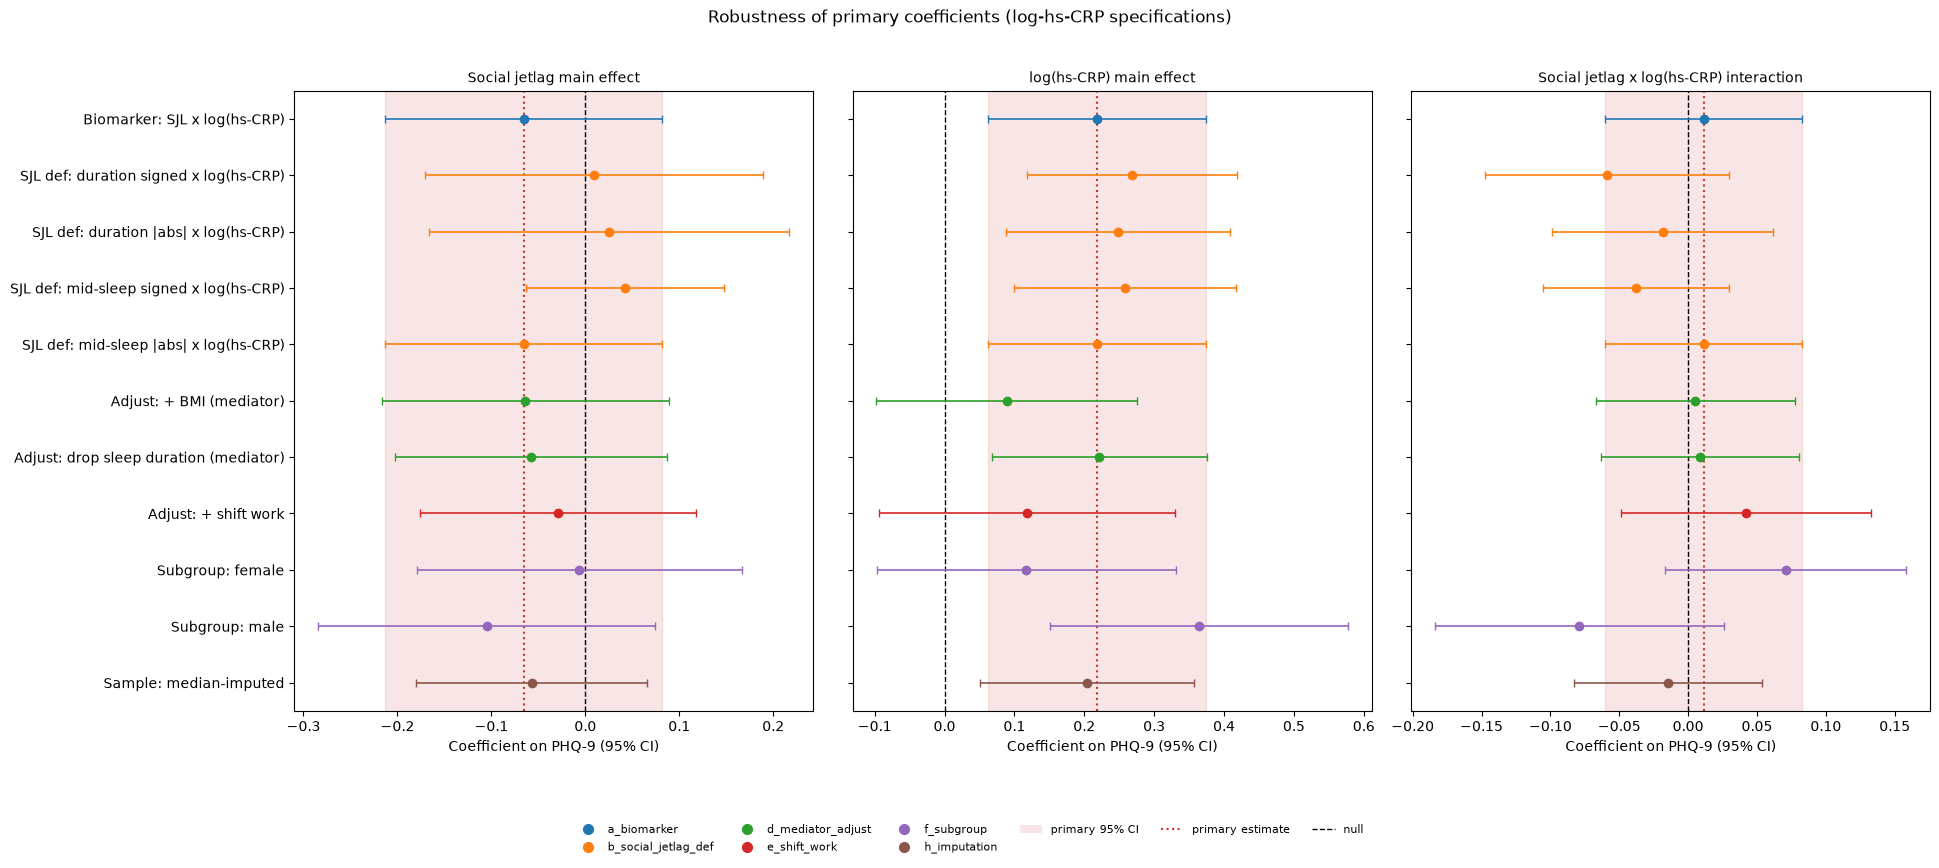

Saved: c:\Users\lime1t\OneDrive - Novartis Pharma AG\Work\Training\MADS\Course material\699_Capstone\capstone\reports\figures\sensitivity_forest.png


In [14]:
# Scale-comparable rows: continuous PHQ-9 outcome and the primary log(hs-CRP) biomarker.
comparable = comparison[
    (comparison["family"] == "gaussian")
    & (comparison["outcome"] == "phq9_score")
    & (comparison["biomarker"] == PRIMARY_BIOMARKER)
    & (comparison["error"].isna())
].copy()

ROLE_TITLES = {
    "exposure_main": "Social jetlag main effect",
    "biomarker_main": "log(hs-CRP) main effect",
    "interaction": "Social jetlag x log(hs-CRP) interaction",
}
roles_to_plot = [
    r for r in ["exposure_main", "biomarker_main", "interaction"]
    if (comparable["reported"] == r).any()
]

groups = sorted(comparable["group"].unique())
cmap = plt.get_cmap("tab10")
group_colors = {g: cmap(i % 10) for i, g in enumerate(groups)}

label_order = (
    comparable[["group", "label"]].drop_duplicates()
    .sort_values(["group", "label"]).reset_index(drop=True)
)
label_positions = {lab: i for i, lab in enumerate(label_order["label"])}

fig, axes = plt.subplots(
    1, len(roles_to_plot),
    figsize=(6.5 * len(roles_to_plot), 0.45 * len(label_positions) + 2.5),
    sharey=True, squeeze=False,
)

for ax, role in zip(axes[0], roles_to_plot):
    sub = comparable[comparable["reported"] == role].copy()
    sub["y"] = sub["label"].map(label_positions)

    # Primary model estimate and CI from 03.
    ref = primary_by_role.get(role, {}).get("estimate", np.nan)
    ref_low = primary_by_role.get(role, {}).get("ci_low", np.nan)
    ref_high = primary_by_role.get(role, {}).get("ci_high", np.nan)

    # Shaded reference CI band, then lines for null and point estimate.
    if np.isfinite(ref_low) and np.isfinite(ref_high):
        ax.axvspan(ref_low, ref_high, color="#c0392b", alpha=0.12, zorder=0)
    ax.axvline(0.0, color="black", linestyle="--", linewidth=1, zorder=1)
    if np.isfinite(ref):
        ax.axvline(ref, color="#c0392b", linestyle=":", linewidth=1.5, zorder=2)

    for g in groups:
        gsub = sub[sub["group"] == g]
        if gsub.empty:
            continue
        ax.errorbar(
            gsub["estimate"], gsub["y"],
            xerr=[gsub["estimate"] - gsub["ci_low"], gsub["ci_high"] - gsub["estimate"]],
            fmt="o", color=group_colors[g], ecolor=group_colors[g],
            capsize=3, markersize=6, linewidth=1.2, label=g, zorder=3,
        )

    ax.set_title(ROLE_TITLES.get(role, role), fontsize=10)
    ax.set_xlabel("Coefficient on PHQ-9 (95% CI)")

axes[0][0].set_yticks(list(label_positions.values()))
axes[0][0].set_yticklabels(list(label_positions.keys()))
axes[0][0].invert_yaxis()

from matplotlib.lines import Line2D
from matplotlib.patches import Patch

legend_handles = [
    Line2D([0], [0], marker="o", color=group_colors[g], linestyle="", markersize=7, label=g)
    for g in groups
]
legend_handles += [
    Patch(facecolor="#c0392b", edgecolor="none", alpha=0.12, label="primary 95% CI"),
    Line2D([0], [0], color="#c0392b", linestyle=":", linewidth=1.5, label="primary estimate"),
    Line2D([0], [0], color="black", linestyle="--", linewidth=1, label="null"),
]
fig.legend(
    handles=legend_handles,
    loc="upper center",
    ncol=min(len(legend_handles), 6),
    bbox_to_anchor=(0.5, -0.06),
    fontsize=8,
    frameon=False,
)

fig.suptitle("Robustness of primary coefficients (log-hs-CRP specifications)", y=1.02)
fig.tight_layout()
fig.savefig(FIG_DIR / "sensitivity_forest.png", dpi=200, bbox_inches="tight")
plt.show()
print("Saved:", FIG_DIR / "sensitivity_forest.png")

## 8. Summary and conclusions

**The primary null interaction is robust.** Across every specification, the social jetlag × log(hs-CRP) interaction stays small and never reaches significance. Its sign is unstable (it flips between specs), which is the expected behaviour of a coefficient centred on zero — a hallmark of noise rather than a masked true effect. Redefining social jetlag (signed vs. absolute, mid-sleep vs. duration), recoding the outcome as a binary PHQ‑9 threshold, adding BMI or shift work, dropping sleep duration, imputing missing data, and stratifying by sex all leave the same conclusion: **hs‑CRP does not modify the social jetlag–depression association.**

**Inflammation is associated with depression, but as a main effect.** The log(hs‑CRP) term is consistently positive (~0.2 PHQ‑9 points per log unit) and significant in most specifications, and the alternative biomarker HbA1c behaves similarly. This links higher inflammation/dysglycaemia to greater depressive-symptom severity independent of social jetlag — not through it. (Raw hs‑CRP looks weaker only because its untransformed scale compresses the coefficient; on the log scale the association is clear.)

**Social jetlag alone shows no association with depression.** Its main effect is null under every definition, so the analysis provides no evidence that the timing mismatch itself predicts PHQ‑9, with or without an inflammatory pathway.

**Direction of association favours depression → inflammation.** The reverse-direction models are informative: higher PHQ‑9 predicts higher log(hs‑CRP) and higher HbA1c, but PHQ‑9 does **not** predict social jetlag. This is more consistent with depression driving inflammatory/metabolic markers than with social jetlag operating through inflammation, and it cautions against a causal reading of the biomarker main effect.

**Conclusion** The primary study conclusion is well supported: there is a robust inflammation–depression association but **no evidence that hs‑CRP amplifies a social-jetlag effect on depression**. The interaction hypothesis is not supported, while the biomarker main effect is the stable, reproducible signal, most plausibly reflecting a depression → inflammation direction that future longitudinal work should test directly.

_The cell below is a technical check only: it flags any specification whose model fit returned an error._


In [16]:
# Technical check: report any specification whose survey-weighted fit failed.
n_failed = int(grid["error"].notna().sum())
if n_failed:
    print(f"Model fits with errors (rows): {n_failed}")
    print(grid.loc[grid["error"].notna(), ["label", "reported", "error"]].to_string(index=False))
else:
    print("All specifications fit successfully (0 errors).")


All specifications fit successfully (0 errors).
